# Multi-Curve Multi-Theta Calibration — Base Testing

## Overview

THere are two calibration approaches for the stochastic volatility Hull-White model with time-varying mean reversion $\theta(t)$. Each version addresses different aspects of the optimization problem.

| Version | Gradient Method | Loss Function | Key Features | Status |
|---------|----------------|---------------|--------------|--------|
| **v1** | Forward differences | Price RMSE | Fast, simple numerical gradients | ✅ Working |
| **v2** | Central differences | Implied vol RMSE | More accurate gradients, vol-based loss | ✅ Working |

---

## Data
Three data sources:

1. **OIS Forward Curve** - risk-free discounting curve
2. **Key Rate Forward Curve** - policy rate curve for caplet payoffs
3. **Volatility Surface** - calibration target (implied rates vols)

In [11]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load market data
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

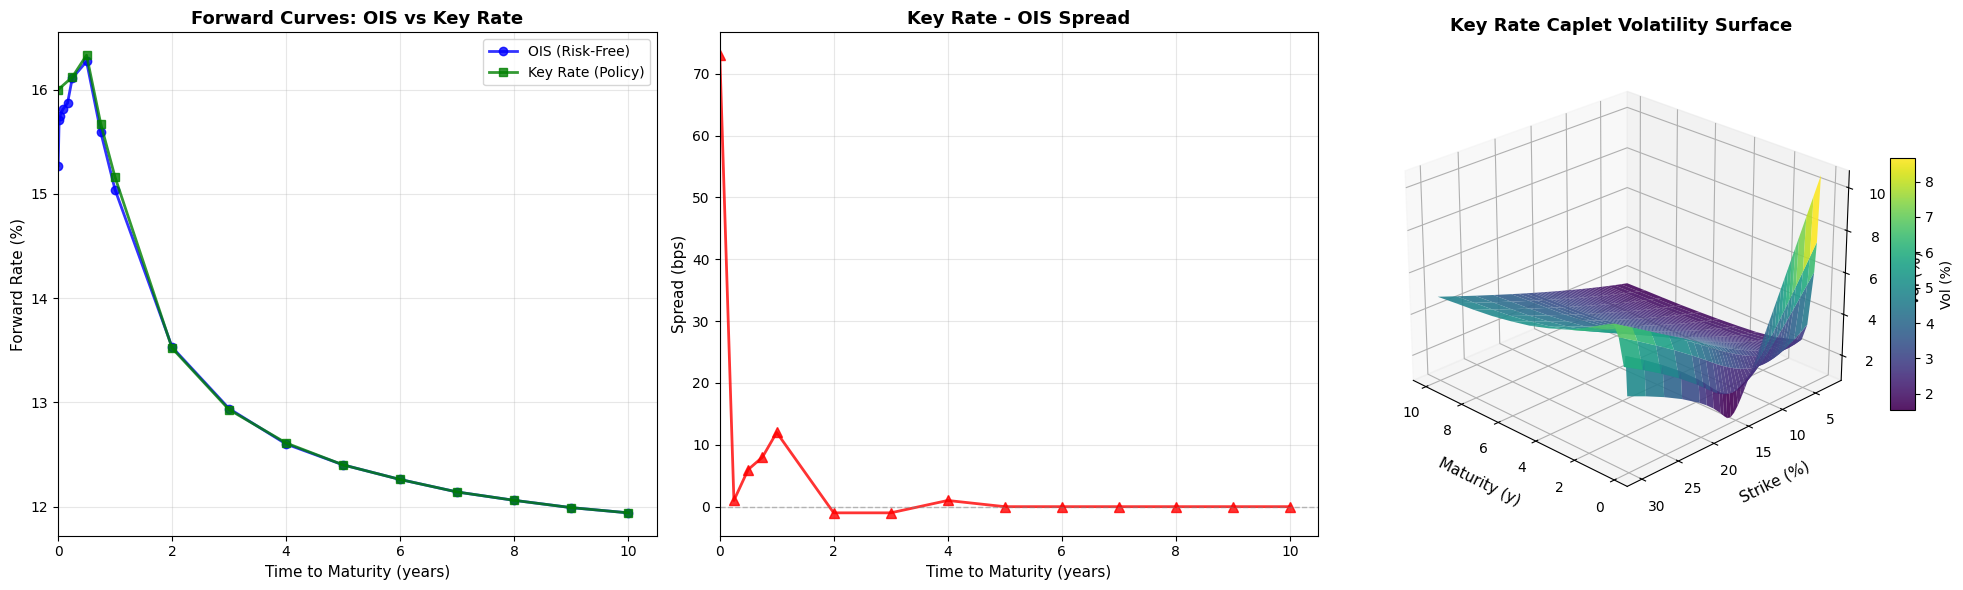

In [12]:
# Visualize all three data sources
fig = plt.figure(figsize=(20, 6))

# 1. Forward Curves Comparison (Left)
ax1 = fig.add_subplot(131)
ax1.plot(fwd_ois['time_to_maturity'], fwd_ois['forward_rate'] * 100, 'b-o', 
         linewidth=2, markersize=6, label='OIS (Risk-Free)', alpha=0.8)
ax1.plot(fwd_key_rate['time_to_maturity'], fwd_key_rate['forward_rate'] * 100, 'g-s', 
         linewidth=2, markersize=6, label='Key Rate (Policy)', alpha=0.8)
ax1.set_xlabel('Time to Maturity (years)', fontsize=11)
ax1.set_ylabel('Forward Rate (%)', fontsize=11)
ax1.set_title('Forward Curves: OIS vs Key Rate', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 10.5)

# 2. Spread Curve (Center)
ax2 = fig.add_subplot(132)
# Align tenors for spread calculation
common_tenors = set(fwd_ois['time_to_maturity']).intersection(set(fwd_key_rate['time_to_maturity']))
spread_data = []
for tenor in sorted(common_tenors):
    ois_rate = fwd_ois[fwd_ois['time_to_maturity'] == tenor]['forward_rate'].values[0]
    key_rate = fwd_key_rate[fwd_key_rate['time_to_maturity'] == tenor]['forward_rate'].values[0]
    spread_data.append((tenor, (key_rate - ois_rate) * 10000))  # Convert to basis points

spread_tenors, spread_bps = zip(*spread_data) if spread_data else ([], [])
ax2.plot(spread_tenors, spread_bps, 'r-^', linewidth=2, markersize=7, alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Time to Maturity (years)', fontsize=11)
ax2.set_ylabel('Spread (bps)', fontsize=11)
ax2.set_title('Key Rate - OIS Spread', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 10.5)

# 3. Volatility Surface - 3D (Right)
ax3 = fig.add_subplot(133, projection='3d')
maturities = sorted(vol_key_rate['time_to_maturity'].unique())
strikes = sorted(vol_key_rate['strike'].unique())
T_grid, K_grid = np.meshgrid(maturities, strikes)
vol_grid = np.zeros_like(T_grid)
for i, k in enumerate(strikes):
    for j, t in enumerate(maturities):
        row = vol_key_rate[(vol_key_rate['time_to_maturity'] == t) & (vol_key_rate['strike'] == k)]
        vol_grid[i, j] = row['implied_normal_vol'].values[0] * 100 if len(row) > 0 else np.nan

surf = ax3.plot_surface(T_grid, K_grid * 100, vol_grid, cmap='viridis', alpha=0.9, edgecolor='none')
ax3.set_xlabel('Maturity (y)', fontsize=11, labelpad=8)
ax3.set_ylabel('Strike (%)', fontsize=11, labelpad=8)
ax3.set_zlabel('Vol (%)', fontsize=11, labelpad=8)
ax3.set_title('Key Rate Caplet Volatility Surface', fontsize=13, fontweight='bold', pad=10)
ax3.view_init(elev=25, azim=135)
fig.colorbar(surf, ax=ax3, shrink=0.5, aspect=10, label='Vol (%)')

plt.tight_layout()
plt.show()

## Vol Surface Utilities

Import reusable functions for generating and visualizing model volatility surfaces.

In [ ]:
# Import vol surface utilities from shared module
from ap.caplet_vol_surface import generate_caplet_vol_surface, plot_caplet_vol_surface

# Backward-compatible wrapper (old signature had unused 'model' arg)
def generate_vol_surface(model, vol_key_rate, fwd_key_rate, version_name="Model"):
    """Wrapper for backward compatibility."""
    return generate_caplet_vol_surface(vol_key_rate, fwd_key_rate, version_name)

def plot_vol_surface_comparison(vol_results, version_name="Model", plot_maturities=[1.0, 3.0, 5.0, 7.0, 10.0]):
    """Wrapper for backward compatibility."""
    return plot_caplet_vol_surface(vol_results, version_name, plot_maturities)

print("Vol surface utilities loaded from pyquant.caplet_vol_surface")



## Mathematical Model

### Model Parameters

**Calibration targets:** $\{\theta_1, \theta_2, \ldots, \theta_n\}$ and $\varepsilon$

| Parameter | Symbol | Role | Typical Range |
|-----------|--------|------|---------------|
| Initial variance | $v_0$ | Starting volatility level | 0.0001 - 0.001 |
| Mean reversion speed | $\kappa$ | How fast v(t) reverts to θ(t) | 0.1 - 1.0 |
| **Theta curve** | $\theta(t)$ | **Time-varying target variance** | **0.001 - 0.02** |
| Vol-of-vol | $\varepsilon$ | Variance of variance (smile curvature) | 0.05 - 0.5 |
| HW mean reversion | $\lambda$ | Short rate mean reversion | 0.1 - 0.5 |
| Spread mean reversion | $\gamma$ | Spread process reversion | 0.1 - 0.5 |
| Spread vol | $\xi$ | Spread volatility | 0.005 - 0.02 |

---

### Model Equations

**CIR Variance Process:**
$$dv_t = \kappa \left( \theta(t) - v_t \right) dt + \varepsilon \sqrt{v_t} \, dW_t^v$$

where $\theta(t) = \text{PCHIP}\left(t; \{(T_i, \theta_i)\}_{i=1}^{n}\right)$ interpolates calibrated theta values.

**Hull-White Short Rate (SV Extension):**
$$r_t = f^{\mathrm{OIS}}(t) + x_t, \quad dx_t = -\lambda x_t \, dt + \sqrt{v_t} \, dW_t^x$$

**Key Rate (Dual-Curve):**
$$a_t = r_t + s^{\mathrm{spread}}(t) + k_t, \quad dk_t = -\gamma k_t\,dt + \xi\,dW_t^k$$

**Caplet Pricing:**
$$C = \mathbb{E}^\mathbb{Q}\left[e^{-\int_0^{T+\delta}r_u\,du} \cdot \delta \cdot \left(\frac{1}{\delta}\int_T^{T+\delta} a_u\,du - K\right)^+\right]$$

**Bachelier Formula:**
$$C^{\mathrm{Bach}}(F, K, \sigma, T) = (F-K)\Phi(d) + \sigma\sqrt{T}\phi(d), \quad d = \frac{F-K}{\sigma\sqrt{T}}$$

**Model Vol Approximation:**
$$\sigma_{\mathrm{model}}(T) \approx \sqrt{\theta(T) \cdot \varepsilon}$$

---


## Time-Varying Theta — PCHIP Interpolation

The theta curve $\theta(t)$ is constructed via **PCHIP interpolation** of calibrated nodal values:

$$\theta(t) = \sum_{i=1}^{n-1} \mathbb{1}_{[T_i, T_{i+1})}(t) \cdot P_i(t), \quad P_i(t) = \sum_{j=0}^{3} c_{i,j}(t - T_i)^j$$

where $\{\theta_i\}_{i=1}^{n}$ are calibrated at maturities $0 < T_1 < T_2 < \cdots < T_n$ matching the volatility surface tenors.


In [14]:
# Import pyquant utilities
import sys
sys.path.insert(0, '../..')  # Go up to docs/quant/ where pyquant module lives

import time
import torch
import numpy as np
from scipy.stats import norm

from pyquant.interest_rates import evaluate_timeline, build_fwd_curve, build_ifwd_curve_from_now_starting
# NOTE: Using custom generate_cir_custom (defined below) instead of pyquant version
# from pyquant.heston_sim import generate_cir
from pyquant.torch_spline import PchipSpline1D

time_to_maturities = torch.tensor(
    sorted(vol_key_rate['time_to_maturity'].unique()), 
    dtype=torch.float32
)
# Build forward curve splines using pyquant utilities
ois_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32)
)

key_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32)
)

# Also build integrated forward curves (needed for v2 calibration)
ois_ifwd_curve = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32)
)

key_ifwd_curve = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32)
)

## Simulation Setup

### Timeline Configuration

In [15]:
# Create simulation timeline
T_MAX = 10.0
N_STEPS = 3651  # Daily steps (reduced from 3651 for calibration speed)
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32)

print(f"Timeline: {N_STEPS} steps over {T_MAX}Y")
print(f"  dt = {timeline[1].item():.4f} years (~{timeline[1].item()*365:.1f} days)")

# Initial short rate from OIS curve
r0 = torch.tensor(fwd_ois['forward_rate'].iloc[0], dtype=torch.float32)
print(f"Initial rate r0 = {r0.item()*100:.2f}%")

Timeline: 3651 steps over 10.0Y
  dt = 0.0027 years (~1.0 days)
Initial rate r0 = 15.27%


## Stochastic Process Generators

### CIR Process (Cox-Ingersoll-Ross)

The CIR process for variance $v_t$ follows:

$$dv_t = \kappa(\theta(t) - v_t)dt + \varepsilon\sqrt{v_t}dW_t$$

**Parameters:**
- $\kappa$: Mean reversion speed
- $\theta(t)$: Time-varying long-term mean (calibration target)
- $\varepsilon$: Volatility of variance
- $v_0$: Initial variance

**Feller Condition:** $2\kappa\theta \geq \varepsilon^2$ ensures $v_t > 0$ almost surely.

**Andersen's QE (Quadratic-Exponential) Scheme:**

For a step from $t_i$ to $t_{i+1}$ with $\Delta t = t_{i+1} - t_i$:

1. **Transition parameters** (using $\theta_i$ and $\varepsilon_i$ at current time $t_i$):
   $$\delta = \frac{4\kappa\theta_i}{\varepsilon_i^2}, \quad m = e^{-\kappa\Delta t}, \quad s^2 = \frac{v_i\varepsilon_i^2 m}{\kappa}(1-m) + \frac{\theta_i\varepsilon_i^2}{2\kappa}(1-m)^2$$

2. **Normalized variance:**
   $$\psi = \frac{s^2}{m^2}$$

3. **Sample $v_{i+1}$** from noncentral chi-square scaled distribution:
   $$\bar{c} = \frac{\varepsilon_i^2(1-m)}{4\kappa}, \quad \bar{\kappa} = \frac{4\kappa m \cdot v_i}{\varepsilon_i^2(1-m)}$$
   $$v_{i+1} = \bar{c} \cdot \chi^2(\delta, \bar{\kappa})$$

where $\chi^2(\delta, \bar{\kappa})$ is a noncentral chi-square random variable with $\delta$ degrees of freedom and noncentrality parameter $\bar{\kappa}$.

**References:**
- Andersen, L.B. (2007). "Efficient simulation of the Heston stochastic volatility model"
- Grzelak & Oosterlee (2019). "Mathematical Modeling and Computation in Finance"

In [16]:
def noncentral_chisquare(df: torch.Tensor, nonc: torch.Tensor) -> torch.Tensor:
    """
    Generate samples from noncentral chi-square distribution using Andersen's QE scheme.
    
    Args:
        df: Degrees of freedom δ (must be > 0)
        nonc: Non-centrality parameter κ̄ (must be ≥ 0)
    
    Returns:
        Samples from χ²(δ, κ̄)
    """
    PSI_CRIT = 1.5  # Threshold for switching between sampling methods
    
    # Moments of noncentral chi-square
    m = df + nonc
    s2 = 2*df + 4*nonc
    psi = s2 / (m**2 + 1e-12)
    
    # Quadratic scheme (for ψ ≤ 1.5): approximate as (b√U + √a)²
    psi_inv = 1 / (psi + 1e-12)
    b2 = 2*psi_inv - 1 + torch.sqrt(2*psi_inv) * torch.sqrt(2*psi_inv - 1 + 1e-12)
    a = m / (1 + b2)
    sample_quad = a * (torch.sqrt(b2) + torch.randn_like(a))**2
    
    # Exponential scheme (for ψ > 1.5): mixture of exponential and point mass at 0
    p = (psi - 1) / (psi + 1)
    beta = (1 - p) / (m + 1e-12)
    u = torch.rand_like(p)
    sample_exp = torch.where(
        u > p,
        torch.log((1 - p) / (1 - u + 1e-12)) / (beta + 1e-12),
        torch.zeros_like(u)
    )
    
    # Select scheme based on ψ
    return torch.where(psi <= PSI_CRIT, sample_quad, sample_exp)


def generate_cir_custom(n_paths, timeline, v0, kappa, theta_t, eps_t, minimum_value=1e-9):
    """
    Generate CIR variance paths using Andersen's QE scheme.
    
    Args:
        n_paths: Number of Monte Carlo paths
        timeline: Time grid (shape: [n_steps+1])
        v0: Initial variance (scalar)
        kappa: Mean reversion speed (scalar)
        theta_t: Time-varying long-term mean (shape: [n_steps+1])
        eps_t: Volatility of variance (scalar or shape: [n_steps+1])
        minimum_value: Floor for variance to ensure v > 0
    
    Returns:
        Variance paths (shape: [n_paths, n_steps+1])
    """
    device = timeline.device
    dt = timeline.diff()  # Shape: [n_steps]
    n_steps = len(dt)
    
    # Initialize paths
    v_paths = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    v_paths[:, 0] = v0
    
    # Handle scalar vs time-varying epsilon
    if eps_t.dim() == 0:  # Scalar
        eps_vec = eps_t.expand(n_steps + 1)
    else:
        eps_vec = eps_t
    
    # Simulate using Andersen's QE scheme
    for i in range(n_steps):
        dt_i = dt[i]
        theta_i = theta_t[i]  # Use θ at CURRENT time (not i+1)
        eps_i = eps_vec[i]     # Use ε at CURRENT time
        v_curr = v_paths[:, i]
        
        # QE scheme parameters
        exp_term = torch.exp(-kappa * dt_i)
        one_minus_exp = 1 - exp_term
        
        # Numerical stability: avoid division by zero
        denom = eps_i**2 * (one_minus_exp + 1e-12)
        
        # Scaled variance and noncentrality
        c_bar = one_minus_exp / (4 * kappa + 1e-12) * eps_i**2
        kappa_bar = 4 * kappa * exp_term * v_curr / denom
        
        # Degrees of freedom (Feller condition: δ > 0 requires 2κθ ≥ ε²)
        delta = 4 * kappa * theta_i / (eps_i**2 + 1e-12)
        
        # Sample from scaled noncentral chi-square
        v_next = c_bar * noncentral_chisquare(delta, kappa_bar)
        
        # Apply floor to prevent numerical issues
        if minimum_value is not None:
            v_next = torch.clamp(v_next, min=minimum_value)
        
        v_paths[:, i+1] = v_next
    
    return v_paths

In [17]:
# Hull-White rate innovation with stochastic variance
def generate_hw_sv(n_paths, timeline, x0, lam, v_paths):
    """Hull-White Ornstein-Uhlenbeck process with time-varying variance."""
    device = timeline.device
    dt = timeline.diff()
    n_steps = len(dt)
    
    x_paths = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    x_paths[:, 0] = x0
    
    for i in range(n_steps):
        x = x_paths[:, i]
        v = v_paths[:, i]
        
        dW = torch.randn(n_paths, device=device) * torch.sqrt(dt[i])
        # OU with stochastic volatility: dx = -λx dt + √v dW
        x_next = x * torch.exp(-lam * dt[i]) + torch.sqrt(torch.clamp(v, min=1e-9)) * dW
        x_paths[:, i + 1] = x_next
    
    return x_paths

# OU spread process (dual-curve spread dynamics)
def generate_ou_spread(n_paths, timeline, k0, gamma, xi):
    device = timeline.device
    dt = timeline.diff()
    n_steps = len(dt)
    
    k_paths = torch.zeros((n_paths, n_steps + 1), dtype=torch.float32, device=device)
    k_paths[:, 0] = k0
    
    for i in range(n_steps):
        k = k_paths[:, i]
        dW = torch.randn(n_paths, device=device) * torch.sqrt(dt[i])
        # dk = -γk dt + ξ dW
        k_next = k * torch.exp(-gamma * dt[i]) + xi * dW
        k_paths[:, i + 1] = k_next
    
    return k_paths

In [18]:
# Model orchestration: combine CIR + HW + Spread processes
def create_key_rate_model(timeline, n_paths, key_fwd_spline, ois_fwd_spline, r0, a0, 
                           v0, kappa, theta_t, eps_t, x0, lam, k0, gamma, xi):
    """
    Create simulated paths for the dual-curve HWH model.
    
    Uses custom generate_cir_custom for CIR variance process with time-varying θ(t).
    
    Returns dict with:
        - 'ois_rate_paths': r_t = f_OIS(t) + x_t
        - 'key_rate_paths': a_t = r_t + s_spread(t) + k_t  
        - 'variance_paths': v_t (CIR process)
        - 'timeline': time grid
    """
    # CIR variance using CUSTOM implementation (correct time indexing for θ(t))
    eps_val = eps_t if eps_t.dim() > 0 else eps_t
    v_paths = generate_cir_custom(
        n_paths=n_paths,
        timeline=timeline,
        v0=v0,
        kappa=kappa,
        theta_t=theta_t,  # Time-varying theta tensor
        eps_t=eps_val,    # Can be scalar or time-varying
        minimum_value=1e-9
    )
    # Output shape is already (n_paths, n_steps+1) - no need to squeeze
    
    # Hull-White innovation
    x_paths = generate_hw_sv(n_paths, timeline, x0, lam, v_paths)
    
    # Spread innovation  
    k_paths = generate_ou_spread(n_paths, timeline, k0, gamma, xi)
    
    # OIS rate: r_t = f_OIS(t) + x_t
    if isinstance(ois_fwd_spline, PchipSpline1D):
        f_ois_t = ois_fwd_spline.evaluate(timeline)
    else:
        f_ois_t = ois_fwd_spline.mean()  # Fallback for tensor
    r_paths = f_ois_t.unsqueeze(0) + x_paths if f_ois_t.dim() == 1 else ois_fwd_spline.mean() + x_paths
    
    # Key rate: a_t = f_KEY(t) + x_t + k_t (dual curve with spread)
    if isinstance(key_fwd_spline, PchipSpline1D):
        f_key_t = key_fwd_spline.evaluate(timeline)
        a_paths = f_key_t.unsqueeze(0) + x_paths + k_paths
    else:
        spread = key_fwd_spline.mean() - (f_ois_t.mean() if f_ois_t.dim() == 1 else ois_fwd_spline.mean())
        a_paths = r_paths + spread + k_paths
    
    return {
        'ois_rate_paths': r_paths,
        'key_rate_paths': a_paths,
        'variance_paths': v_paths,
        'timeline': timeline,
        'n_paths': n_paths
    }

# Caplet pricing via Monte Carlo
def price_key_caplet_surface(model, vol_key_rate_df, fwd_key_rate_df):
    """
    Price caplets using MC simulation and compare to market.
    
    Returns:
        - loss_vol: MSE between model and market caplet PVs
        - loss_fwd: forward rate penalty
    """
    timeline = model['timeline']
    a_paths = model['key_rate_paths']
    r_paths = model['ois_rate_paths']
    dt = timeline.diff()
    
    model_pvs = []
    market_pvs = []
    
    for idx, row in vol_key_rate_df.iterrows():
        T_fix = row['time_to_maturity']
        K = row['strike']
        sigma_mkt = row['implied_normal_vol']
        tau = 0.25  # Quarterly caplet accrual period
        
        # Find indices for fixing time T_fix and payment time T_fix + tau
        idx_fix_start = torch.argmin(torch.abs(timeline - T_fix))
        idx_fix_end = torch.argmin(torch.abs(timeline - (T_fix + tau)))
        
        # CRITICAL FIX: Compute realized forward rate as average over accrual period [T_fix, T_fix+tau]
        # L(T_fix, T_fix+tau) = (1/tau) * integral from T_fix to T_fix+tau of a_u du
        if idx_fix_end > idx_fix_start:
            # Trapezoidal integration over accrual period
            a_accrual = a_paths[:, idx_fix_start:idx_fix_end+1]
            dt_accrual = timeline[idx_fix_start:idx_fix_end+1].diff()
            # Weighted average: sum(a_t * dt) / sum(dt) 
            L_realized = (a_accrual[:, :-1] * dt_accrual.unsqueeze(0)).sum(dim=1) / dt_accrual.sum()
        else:
            # Edge case: use spot rate if accrual period too short
            L_realized = a_paths[:, idx_fix_start]
        
        # CRITICAL FIX: Path-wise discount factor from 0 to T_fix+tau
        # D(0, T_fix+tau) = exp(-integral from 0 to T_fix+tau of r_u du)
        r_discount = r_paths[:, :idx_fix_end+1]
        dt_discount = timeline[:idx_fix_end+1].diff()
        # Trapezoidal integration: sum(r_t * dt) for each path
        integral_r = (r_discount[:, :-1] * dt_discount.unsqueeze(0)).sum(dim=1)
        P_disc_paths = torch.exp(-integral_r)
        
        # Caplet payoff: tau * (L - K)+ * D(0, T_fix+tau)
        payoff = torch.clamp(L_realized - K, min=0) * tau * P_disc_paths
        pv_model = payoff.mean()
        
        # Market PV from Bachelier (using proper discount factor)
        F = fwd_key_rate_df[fwd_key_rate_df['time_to_maturity'] == T_fix]['forward_rate'].values
        F = F[0] if len(F) > 0 else K
        P_disc_market = P_disc_paths.mean().item()  # Use average discount from simulation
        d = (F - K) / (sigma_mkt * np.sqrt(T_fix) + 1e-10)
        pv_market = tau * P_disc_market * ((F - K) * norm.cdf(d) + sigma_mkt * np.sqrt(T_fix) * norm.pdf(d))
        
        model_pvs.append(pv_model.item())
        market_pvs.append(pv_market)
        
        # Store for analysis
        vol_key_rate_df.at[idx, 'pv_model_key'] = pv_model.item()
        vol_key_rate_df.at[idx, 'pv'] = pv_market
    
    # Absolute MSE loss (price errors)
    model_pvs_t = torch.tensor(model_pvs)
    market_pvs_t = torch.tensor(market_pvs)
    loss_vol = torch.mean((model_pvs_t - market_pvs_t) ** 2)
    
    # Forward rate penalty (keep model rates reasonable)
    fwd_model = a_paths.mean()
    fwd_market = torch.tensor(fwd_key_rate_df['forward_rate'].mean())
    loss_fwd = (fwd_model - fwd_market) ** 2
    
    return loss_vol, loss_fwd

In [19]:
# QUICK TEST: Verify forward curve anchoring fix
import pickle
print("="*70)
print("FORWARD CURVE ANCHORING VERIFICATION")
print("="*70)

# Test forward curve at t=0
test_times = torch.tensor([0.0, 0.001, 0.01, 0.1, 1.0, 5.0, 10.0])

print("\nKey Rate Forward Curve (f_KEY):")
for t in test_times:
    val = key_fwd_spline.evaluate(t).item()
    print(f"  f_KEY({t:.3f}) = {val*100:.4f}%")

print("\nOIS Forward Curve (f_OIS):")
for t in test_times:
    val = ois_fwd_spline.evaluate(t).item()
    print(f"  f_OIS({t:.3f}) = {val*100:.4f}%")

print("\n" + "="*70)
print("QUICK SIMULATION TEST (1000 paths)")
print("="*70)

# Quick simulation with default parameters to check forward bias
theta_test = 0.01 * torch.ones_like(time_to_maturities)
eps_test = torch.tensor(0.2)
theta_t_test = evaluate_timeline(timeline, time_to_maturities, theta_test)

with torch.no_grad():
    model_test = create_key_rate_model(
        timeline, 1000, key_fwd_spline, ois_fwd_spline,
        r0, r0, torch.tensor(0.0001), torch.tensor(0.5), theta_t_test, eps_test,
        torch.tensor(0.0), torch.tensor(0.3), torch.tensor(0.0), torch.tensor(0.2), torch.tensor(0.01)
    )

a_paths_test = model_test['key_rate_paths']

# Check forward rate at multiple maturities
print(f"\n{'Maturity':<10} {'Market F':<12} {'Simulated L':<15} {'Bias (bps)':<12}")
print("-"*50)

for T in [0.0, 1.0, 3.0, 5.0, 10.0]:
    if T > 10.0:
        continue
    
    market_fwd = key_fwd_spline.evaluate(torch.tensor([T])).item()
    
    if T == 0.0:
        sim_fwd = a_paths_test[:, 0].mean().item()
    else:
        idx = int(T / 10.0 * (len(timeline)-1))
        sim_fwd = a_paths_test[:, idx].mean().item()
    
    bias_bps = (sim_fwd - market_fwd) * 10000
    print(f"{T:<10.1f} {market_fwd*100:<12.2f}% {sim_fwd*100:<15.4f}% {bias_bps:<12.0f}")

print("\n" + "="*70)
print("EXPECTED: Bias should be near zero (< ±100 bps) at all maturities")
print("BEFORE FIX: Bias was ~1600 bps at t=0, growing to ~5000 bps at t=10")
print("="*70)

FORWARD CURVE ANCHORING VERIFICATION

Key Rate Forward Curve (f_KEY):
  f_KEY(0.000) = 16.0000%
  f_KEY(0.001) = 16.0000%
  f_KEY(0.010) = 16.0002%
  f_KEY(0.100) = 16.0268%
  f_KEY(1.000) = 15.1600%
  f_KEY(5.000) = 12.4000%
  f_KEY(10.000) = 11.9400%

OIS Forward Curve (f_OIS):
  f_OIS(0.000) = 15.2700%
  f_OIS(0.001) = 15.2700%
  f_OIS(0.010) = 15.4446%
  f_OIS(0.100) = 15.8234%
  f_OIS(1.000) = 15.0400%
  f_OIS(5.000) = 12.4000%
  f_OIS(10.000) = 11.9400%

QUICK SIMULATION TEST (1000 paths)

Maturity   Market F     Simulated L     Bias (bps)  
--------------------------------------------------
0.0        16.00       % 16.0000        % -0          
1.0        15.16       % 15.3530        % 19          
3.0        12.93       % 12.8415        % -9          
5.0        12.40       % 12.0692        % -33         
10.0       11.94       % 12.7591        % 82          

EXPECTED: Bias should be near zero (< ±100 bps) at all maturities
BEFORE FIX: Bias was ~1600 bps at t=0, growing to ~50

## v1 Calibration - Price-Based Loss (Baseline) <a name="v1-calibration"></a>

### Price Loss Function Test

The very first calibration attempt. Minimizes **price errors** directly with numerical gradients:

$$\mathcal{L}_{\text{price}} = \sum_{i,j} \left( P_{ij}^{\text{model}} - P_{ij}^{\text{market}} \right)^2$$

V1 CALIBRATION - BASELINE (Numerical Gradients + CRN)
Timeline verification: 3651 steps over 10.0 years
  dt = 0.002739 years (1.00 days)

Calibrating 15 θ parameters + 1 ε parameter
Initial: θ̄=0.01000, ε=0.1200
Initial √(θ·ε) = 3.46%
Market vol avg: 3.29%
Using CRN for variance reduction + gradient clipping (max=1.000)

Starting calibration...
Iter   1: Loss=2.1883e-05, θ̄=0.00996, ε=0.1200, √(θε)=3.46%, LR=5.00e+00, grad_raw=4.75e-05, grad_ema=4.75e-05
Iter   6: Loss=2.2714e-05, θ̄=0.00982, ε=0.1201, √(θε)=3.43%, LR=4.99e+00, grad_raw=2.34e-05, grad_ema=2.85e-05
Iter  11: Loss=2.2047e-05, θ̄=0.00969, ε=0.1200, √(θε)=3.41%, LR=4.98e+00, grad_raw=4.55e-05, grad_ema=3.86e-05
Iter  16: Loss=2.2746e-05, θ̄=0.00956, ε=0.1201, √(θε)=3.39%, LR=4.96e+00, grad_raw=3.43e-05, grad_ema=2.92e-05
Iter  21: Loss=2.2354e-05, θ̄=0.00943, ε=0.1200, √(θε)=3.36%, LR=4.95e+00, grad_raw=4.19e-05, grad_ema=3.78e-05
Iter  26: Loss=2.2423e-05, θ̄=0.00931, ε=0.1200, √(θε)=3.34%, LR=4.94e+00, grad_raw=3.57e-05

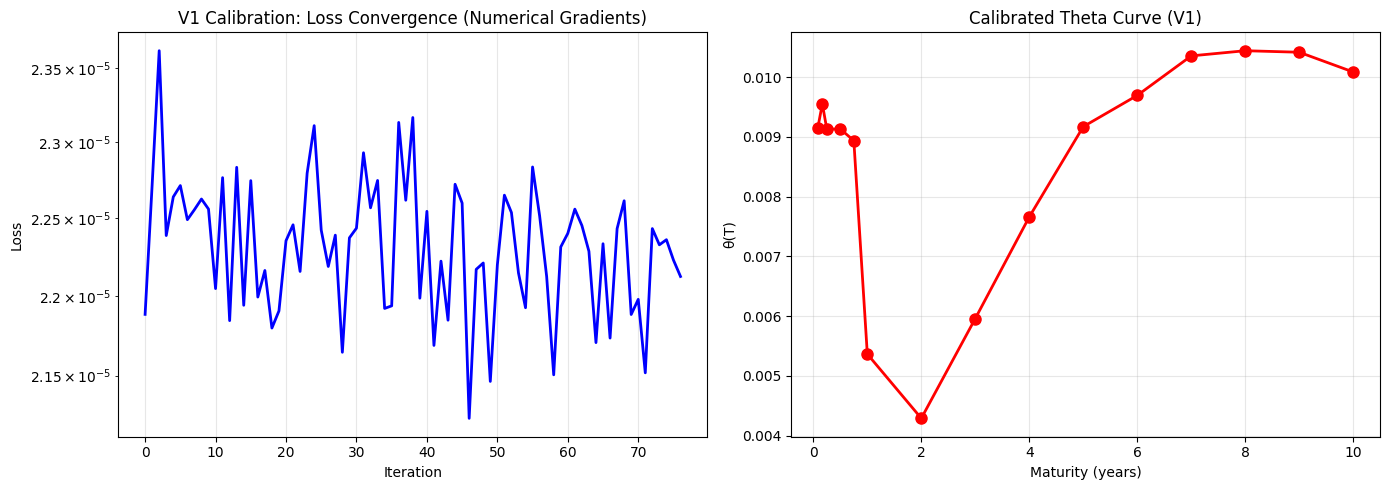

✅ V1 calibration complete and plot saved


In [20]:
# v1 Calibration - Baseline with numerical gradients (FIXED)

print("="*70)
print("V1 CALIBRATION - BASELINE (Numerical Gradients + CRN)")
print("="*70)

# Verify timeline is daily (3650 steps)
print(f"Timeline verification: {len(timeline)-1} steps over {timeline[-1]:.1f} years")
print(f"  dt = {timeline[1].item():.6f} years ({timeline[1].item()*365:.2f} days)\n")

# Initialize calibration parameters - BETTER STARTING POINT
market_vol_avg = vol_key_rate['implied_normal_vol'].mean()
target_vol_product = market_vol_avg ** 2  # Target for θ·ε ≈ (0.0329)^2 ≈ 0.00108

# Start closer to target: √(θ·ε) ≈ 3.29%
# If θ ≈ 0.01 and ε ≈ 0.12, then √(0.01 * 0.12) ≈ 3.46%
theta_values_v1 = 0.01 * torch.ones(len(time_to_maturities), dtype=torch.float32)
epsilon_v1 = torch.tensor(0.12, dtype=torch.float32)

# Fixed model parameters
v0 = torch.tensor(0.0001, dtype=torch.float32)
kappa = torch.tensor(0.5, dtype=torch.float32)
lam = torch.tensor(0.3, dtype=torch.float32)
gamma = torch.tensor(0.2, dtype=torch.float32)
xi = torch.tensor(0.01, dtype=torch.float32)
k0 = torch.tensor(0.0, dtype=torch.float32)
x0 = torch.tensor(0.0, dtype=torch.float32)

# Calibration hyperparameters
lr = 5.0  # INCREASED: loss is ~2e-5, need larger steps
grad_clip = 1.0  # RELAXED: was too aggressive at 0.01

print(f"Calibrating {len(theta_values_v1)} θ parameters + 1 ε parameter")
print(f"Initial: θ̄={theta_values_v1.mean():.5f}, ε={epsilon_v1:.4f}")
print(f"Initial √(θ·ε) = {np.sqrt(theta_values_v1.mean().item()*epsilon_v1.item())*100:.2f}%")
print(f"Market vol avg: {market_vol_avg*100:.2f}%")
print(f"Using CRN for variance reduction + gradient clipping (max={grad_clip:.3f})\n")

def compute_loss_v1(theta_vals, eps_val, n_paths=200, seed=None):  # Added seed parameter for CRN
    """
    Loss function with DAILY timesteps (3650 steps).
    Uses pyquant's evaluate_timeline for PCHIP interpolation.
    
    Args:
        seed: If provided, sets random seed for reproducible MC samples (Common Random Numbers)
    """
    with torch.no_grad():
        # Set seed for Common Random Numbers (CRN) - critical for gradient variance reduction
        if seed is not None:
            torch.manual_seed(seed)
        
        # PCHIP interpolation from pyquant - interpolates theta values onto DAILY timeline
        theta_t = evaluate_timeline(timeline, time_to_maturities, theta_vals)
        eps_t = eps_val * torch.ones_like(timeline)
        
        # Create model using pyquant's generate_cir with DAILY timeline
        model = create_key_rate_model(
            timeline, n_paths, key_fwd_spline, ois_fwd_spline,
            r0, r0 + k0, v0, kappa, theta_t, eps_t, x0, lam, k0, gamma, xi
        )
        
        # Price caplets
        loss_vol, loss_fwd = price_key_caplet_surface(model, vol_key_rate.copy(), fwd_key_rate)
        
        # Check for NaN
        total_loss = loss_vol + 0.001 * loss_fwd
        if torch.isnan(total_loss) or torch.isinf(total_loss):
            return torch.tensor(1e10), loss_vol, loss_fwd
        
        return total_loss, loss_vol, loss_fwd

# Calibration loop with Common Random Numbers (CRN) for variance reduction
best_loss = float('inf')
history_v1 = []
patience = 0

# Gradient smoothing (EMA) - less critical with CRN but still helpful
ema_grad_theta = None
ema_grad_eps = None
ema_beta = 0.5  # REDUCED from 0.7 - trust current gradients more with CRN

import time
start_time = time.time()

print("Starting calibration...")
for iteration in range(300):  # Allow up to 300 iterations (minimum 100 before early stop)
    current_loss, loss_vol, loss_fwd = compute_loss_v1(theta_values_v1, epsilon_v1)
    
    # NaN detection
    if torch.isnan(current_loss) or torch.isinf(current_loss):
        print(f"\n❌ NaN/Inf detected at iteration {iteration+1}!")
        print(f"   θ range: [{theta_values_v1.min():.6f}, {theta_values_v1.max():.6f}]")
        print(f"   ε: {epsilon_v1:.6f}")
        print("   Stopping calibration.")
        break
    
    history_v1.append(current_loss.item())
    
    if current_loss < best_loss:
        best_loss = current_loss.item()
        best_theta_v1 = theta_values_v1.clone()
        best_eps_v1 = epsilon_v1.clone()
        patience = 0
    else:
        patience += 1
        # Only allow early stopping after minimum 50 iterations (reduced from 100)
        if patience >= 30 and iteration >= 50:
            print(f"\nEarly stopping at iteration {iteration+1}")
            break
    
    # Numerical gradients with Common Random Numbers (CRN) - CRITICAL for variance reduction
    h = 1e-2  # INCREASED: was 1e-4, too small for loss scale ~2e-5
    grad_theta = torch.zeros_like(theta_values_v1)
    
    # Gradient for each theta - USE CRN: same seed for baseline and perturbed loss
    for i in range(len(theta_values_v1)):
        seed_i = iteration * 1000 + i  # Unique seed per iteration and parameter
        
        # Baseline loss with this seed
        loss_baseline, _, _ = compute_loss_v1(theta_values_v1, epsilon_v1, n_paths=300, seed=seed_i)
        
        # Perturbed loss with SAME seed (Common Random Numbers)
        theta_perturbed = theta_values_v1.clone()
        theta_perturbed[i] += h
        loss_perturbed, _, _ = compute_loss_v1(theta_perturbed, epsilon_v1, n_paths=300, seed=seed_i)
        
        grad_theta[i] = (loss_perturbed - loss_baseline) / h
    
    # Gradient for epsilon - USE CRN
    seed_eps = iteration * 1000 + len(theta_values_v1)
    loss_baseline_eps, _, _ = compute_loss_v1(theta_values_v1, epsilon_v1, n_paths=300, seed=seed_eps)
    loss_eps_perturbed, _, _ = compute_loss_v1(theta_values_v1, epsilon_v1 + h, n_paths=300, seed=seed_eps)
    grad_eps = (loss_eps_perturbed - loss_baseline_eps) / h
    
    # Clip individual gradients to prevent jumps (BEFORE norm clipping)
    grad_theta = torch.clamp(grad_theta, -grad_clip, grad_clip)
    grad_eps = torch.clamp(grad_eps, -grad_clip, grad_clip)
    
    # Gradient norm clipping for additional stability
    grad_norm = torch.sqrt(torch.sum(grad_theta**2) + grad_eps**2)
    if grad_norm > 1.0:  # Reduced from 10.0 for tighter control
        grad_theta = grad_theta * 1.0 / grad_norm
        grad_eps = grad_eps * 1.0 / grad_norm
    
    # Exponential moving average of gradients to smooth MC noise
    if ema_grad_theta is None:
        ema_grad_theta = grad_theta.clone()
        ema_grad_eps = grad_eps.clone()
    else:
        ema_grad_theta = ema_beta * ema_grad_theta + (1 - ema_beta) * grad_theta
        ema_grad_eps = ema_beta * ema_grad_eps + (1 - ema_beta) * grad_eps
    
    # Update parameters with adaptive LR (very gentle decay) using SMOOTHED gradients
    adaptive_lr = lr / (1.0 + iteration * 0.0005)  # VERY GENTLE decay with CRN
    theta_values_v1 = theta_values_v1 - adaptive_lr * ema_grad_theta
    theta_values_v1 = torch.clamp(theta_values_v1, 1e-5, 0.05)  # Bounds
    
    epsilon_v1 = epsilon_v1 - adaptive_lr * ema_grad_eps  
    epsilon_v1 = torch.clamp(epsilon_v1, 1e-4, 0.5)  # Upper bound
    
    if iteration % 5 == 0:
        sqrt_theta_eps = float(np.sqrt(theta_values_v1.mean().item() * epsilon_v1.item()) * 100)
        ema_grad_norm = torch.sqrt(torch.sum(ema_grad_theta**2) + ema_grad_eps**2).item()
        print(f"Iter {iteration+1:3d}: Loss={current_loss:.4e}, "
              f"θ̄={theta_values_v1.mean():.5f}, ε={epsilon_v1:.4f}, "
              f"√(θε)={sqrt_theta_eps:.2f}%, LR={adaptive_lr:.2e}, grad_raw={grad_norm:.2e}, grad_ema={ema_grad_norm:.2e}")

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"V1 Calibration complete in {elapsed:.1f}s ({len(timeline)-1} daily steps)")
print(f"Final loss: {best_loss:.4e}")
print(f"Final θ range: [{best_theta_v1.min():.5f}, {best_theta_v1.max():.5f}]")
print(f"Final ε: {best_eps_v1:.4f}")
print(f"{'='*70}\n")

# Save v1 checkpoint
import pickle
with open(Path('../../../../data/multi_theta_baseline.pkl'), 'wb') as f:
    pickle.dump({
        'iteration': iteration+1,
        'theta_values': best_theta_v1,
        'epsilon': best_eps_v1,
        'time_to_maturities': time_to_maturities,
        'n_maturities': len(time_to_maturities),
        'loss': best_loss,
        'v0': v0,
        'kappa': kappa,
        'lam': lam,
        'gamma': gamma,
        'xi': xi,
        'k0': k0,
        'history': history_v1
    }, f)
print(f"💾 Saved v1 checkpoint to multi_theta_baseline.pkl\n")

# Plot results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss convergence
axes[0].plot(history_v1, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('V1 Calibration: Loss Convergence (Numerical Gradients)')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Theta curve
axes[1].plot(time_to_maturities.numpy(), theta_values_v1.numpy(), 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('θ(T)')
axes[1].set_title('Calibrated Theta Curve (V1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('v1_calibration_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ V1 calibration complete and plot saved")

## V1 Calibration Results — Volatility Surface Comparison

Using utility functions to generate comprehensive vol surface diagnostics:


V1 VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid inversions:     249 (50.3%)
Failed inversions:    246
  - Bounds violations: 244 (price < intrinsic or invalid)
  - Convergence fails: 2 (bisection didn't converge)
Vol RMSE:             3.804%
Model vol range:      0.01% - 26.84%
Market vol range:     0.97% - 10.58%


📊 Surface Coverage: 249/495 points (50.3%)
   Missing 246 points due to inversion failures



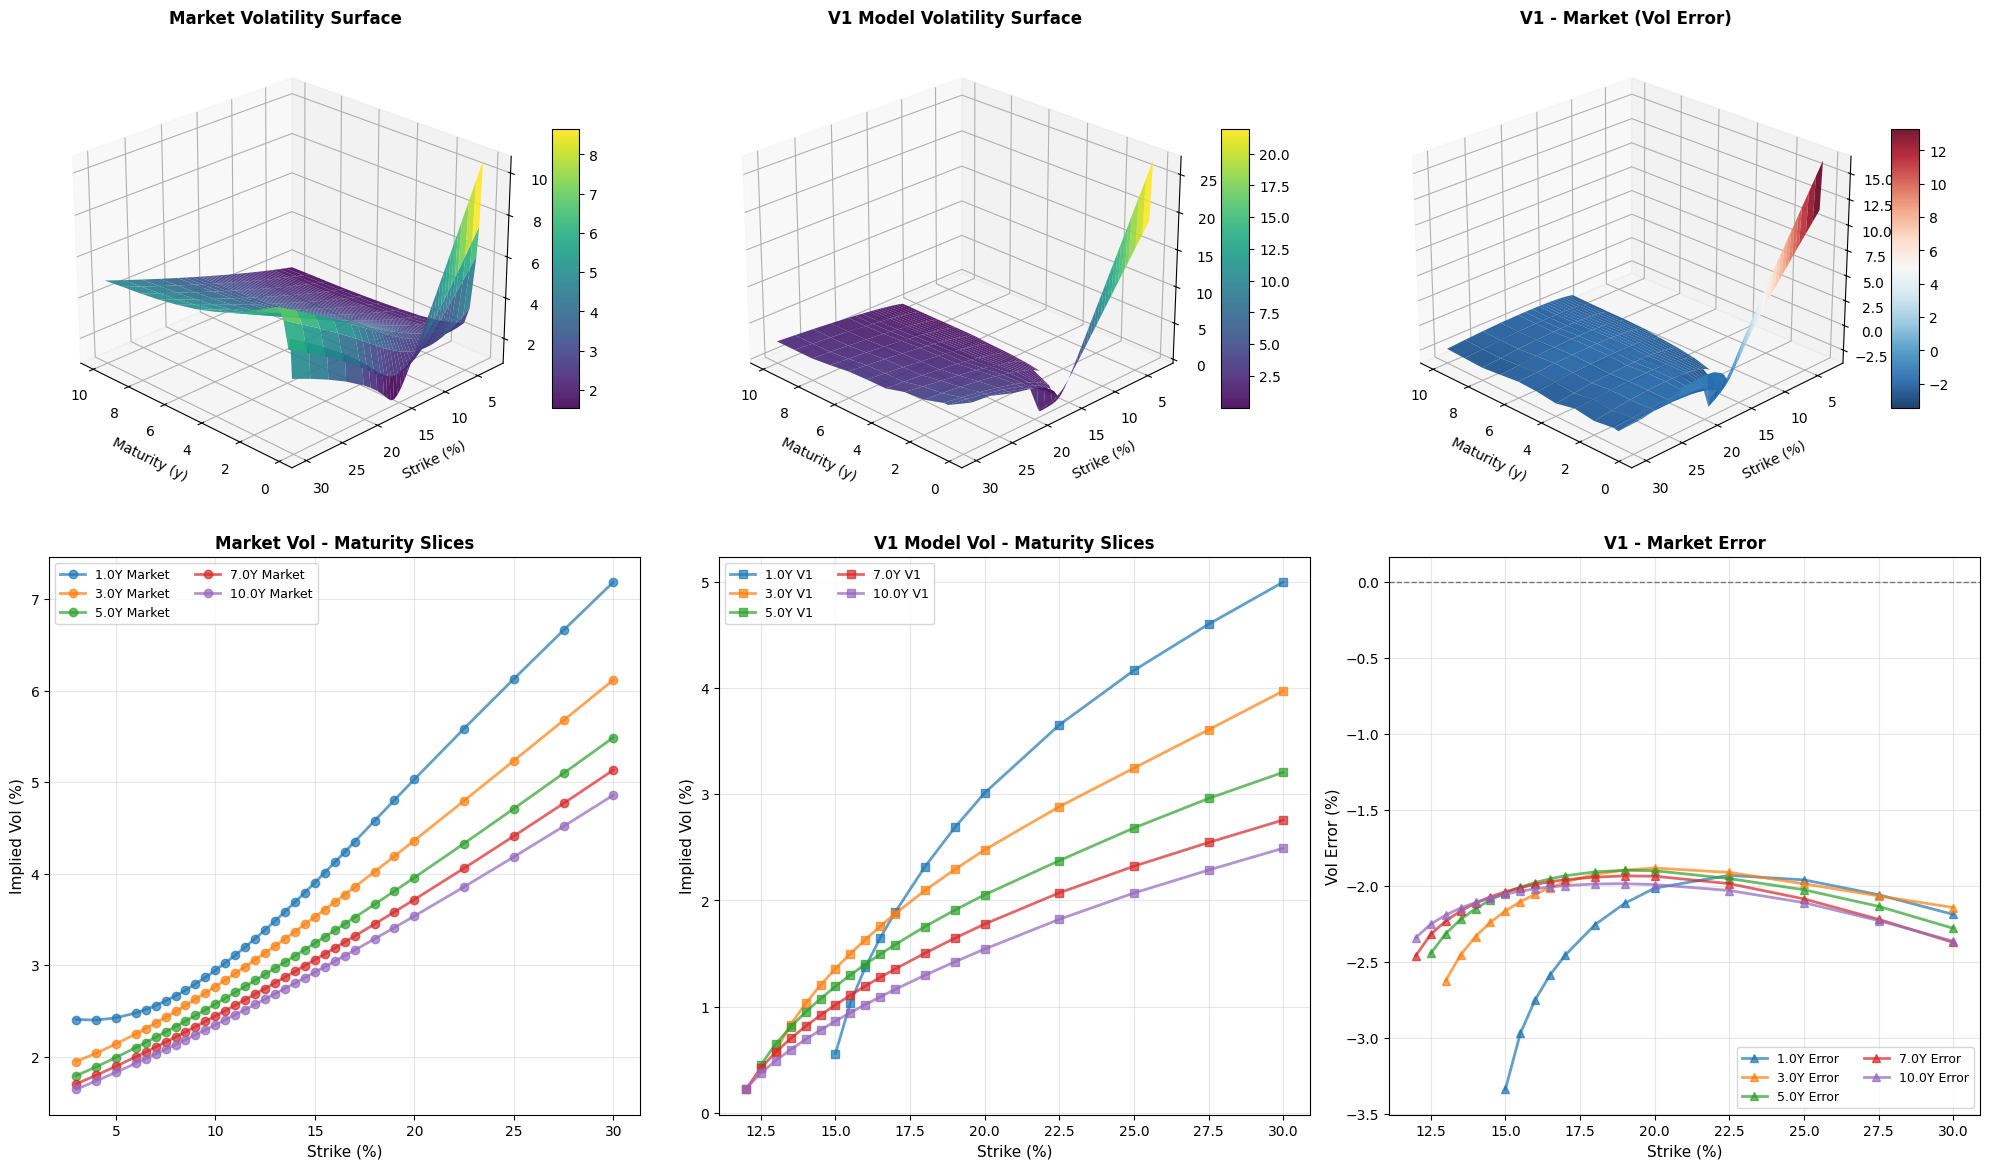

In [21]:
# Re-price with best v1 parameters (using DAILY timeline - 3650 steps)
theta_t_v1 = evaluate_timeline(timeline, time_to_maturities, best_theta_v1)
eps_t_v1 = best_eps_v1 * torch.ones_like(timeline)

model_v1 = create_key_rate_model(
    timeline, 500, key_fwd_spline, ois_fwd_spline,
    r0, r0 + k0, v0, kappa, theta_t_v1, eps_t_v1, x0, lam, k0, gamma, xi
)

vol_data_v1 = vol_key_rate.copy()
price_key_caplet_surface(model_v1, vol_data_v1, fwd_key_rate)

# Generate vol surface with diagnostics
vol_results_v1, vol_rmse_v1 = generate_vol_surface(
    model_v1, vol_data_v1, fwd_key_rate, version_name="v1"
)

# Plot comprehensive vol surface comparison
plot_vol_surface_comparison(
    vol_results_v1,
    version_name="v1",
    plot_maturities=[1.0, 3.0, 5.0, 7.0, 10.0]
)

In [22]:
# DIAGNOSTIC: Analyze why inversions are failing
print("\n" + "="*70)
print("PRICE DISTRIBUTION ANALYSIS - Understanding Inversion Failures")
print("="*70)

# Get forward rates for intrinsic value calculation
fwd_dict = {t: fwd_key_rate[fwd_key_rate['time_to_maturity']==t]['forward_rate'].values[0]
            for t in fwd_key_rate['time_to_maturity'].unique()}

# Analyze all caplets
failed_df = vol_results_v1.copy()  # Use vol_results_v1 which has model_vol_v1 column
failed_df['F'] = failed_df['time_to_maturity'].map(fwd_dict)
failed_df['intrinsic'] = np.maximum(failed_df['F'] - failed_df['strike'], 0)
failed_df['price_to_intrinsic'] = failed_df['pv_model_key'] / (failed_df['intrinsic'] + 1e-10)

# Categorize failures  
failed_df['status'] = 'Valid'
failed_df.loc[failed_df['pv_model_key'] <= 0, 'status'] = 'Price ≤ 0'
failed_df.loc[(failed_df['pv_model_key'] > 0) & (failed_df['pv_model_key'] < failed_df['intrinsic'] * 0.99), 'status'] = 'Price < Intrinsic'
failed_df.loc[failed_df['model_vol_v1'].isna() & (failed_df['status'] == 'Valid'), 'status'] = 'Convergence Fail'

print(f"\nFailure Breakdown:")
for status in failed_df['status'].unique():
    count = (failed_df['status'] == status).sum()
    pct = count / len(failed_df) * 100
    print(f"  {status:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\nPrice Statistics:")
print(f"  Market prices:  min={failed_df['pv'].min():.2e}, max={failed_df['pv'].max():.2e}, mean={failed_df['pv'].mean():.2e}")
print(f"  Model prices:   min={failed_df['pv_model_key'].min():.2e}, max={failed_df['pv_model_key'].max():.2e}, mean={failed_df['pv_model_key'].mean():.2e}")
print(f"  Intrinsic vals: min={failed_df['intrinsic'].min():.2e}, max={failed_df['intrinsic'].max():.2e}, mean={failed_df['intrinsic'].mean():.2e}")

print("="*70 + "\n")


PRICE DISTRIBUTION ANALYSIS - Understanding Inversion Failures

Failure Breakdown:
  Valid               :  249 ( 50.3%)
  Convergence Fail    :    2 (  0.4%)
  Price ≤ 0           :   12 (  2.4%)
  Price < Intrinsic   :  232 ( 46.9%)

Price Statistics:
  Market prices:  min=3.56e-10, max=3.03e-02, mean=5.11e-03
  Model prices:   min=0.00e+00, max=3.09e-02, mean=6.24e-03
  Intrinsic vals: min=0.00e+00, max=1.33e-01, mean=2.75e-02



## V1 Calibration Results — Additional Analysis

(Optional) Additional custom visualizations for v1 calibration quality assessment.

---

In [23]:
# Additional v1 analysis (if needed)
print("V1 calibration complete. Use vol_results_v1 DataFrame for custom analysis.")
print(f"Vol RMSE: {vol_rmse_v1*100:.3f}%")

V1 calibration complete. Use vol_results_v1 DataFrame for custom analysis.
Vol RMSE: 3.804%


## v2 Calibration — Implied Vol Loss + Scaled Parameters

**Objective:** Direct implied volatility-based loss function with improved parameter initialization

$$\mathcal{L} = w_1\cdot\mathcal{L}_{\mathrm{price}} + w_2\cdot\mathcal{L}_{\mathrm{vol}} + w_3\cdot\mathcal{L}_{\mathrm{fwd}}$$

**Features:**
- Proper backward-looking rate averaging: $L(T,T+\delta) = \frac{1}{\delta}\int_T^{T+\delta}a_u\,du$
- Vectorized Bachelier impl vol inversion (Newton-Raphson)
- Full OIS discount validation
- Pre-computed timeline interpolation

**Calibration variables:** $\{\theta_1,\ldots,\theta_n, \varepsilon\}$ with PCHIP smoothing.

---

In [ ]:
# CALIBRATION v2 - Implied Vol Loss + Scaled Initial Params [SLOW]
import time, pickle
from scipy.optimize import brentq
from scipy.stats import norm

print(f"CUDA available: {torch.cuda.is_available()}")
n_maturities = len(time_to_maturities)

# SCALED initial values - targeting market vol ~3.3%
theta_values_v2 = 0.002 * torch.ones(n_maturities, dtype=torch.float32)
epsilon_v2 = torch.tensor(0.5, dtype=torch.float32)
v0_v2, kappa_v2, lam_v2, gamma_v2, xi_v2 = torch.tensor([0.0002, 0.2, 0.15, 0.1, 0.005])
k0_v2, x0_v2 = torch.tensor([0.0, 0.0])

print(f"Calibrating {n_maturities + 1} params ({n_maturities} θ + 1 ε)")
print(f"Initial √(θ·ε) = {np.sqrt(theta_values_v2.mean().item()*epsilon_v2.item())*100:.2f}%  (target ~{vol_key_rate['implied_normal_vol'].mean()*100:.2f}%)")

fwd_dict = {t: fwd_key_rate[fwd_key_rate['time_to_maturity']==t]['forward_rate'].values[0]
            for t in fwd_key_rate['time_to_maturity'].unique()}

def bachelier_price(F, K, sigma, tau):
    if sigma < 1e-10: return max(F - K, 0)
    d = (F - K) / (sigma * np.sqrt(tau))
    return (F - K) * norm.cdf(d) + sigma * np.sqrt(tau) * norm.pdf(d)

def implied_vol_from_price(F, K, price, tau):
    """SLOW: scalar brentq per caplet"""
    intrinsic = max(F - K, 0)
    if price <= intrinsic + 1e-10: return np.nan
    try:
        return brentq(lambda sig: bachelier_price(F, K, sig, tau) - price, 1e-6, 1.0, xtol=1e-8)
    except: return np.nan

def compute_loss_with_vol(theta_vals, eps_val, n_paths=100):
    """
    Vol-based loss with robust error handling.
    Returns vol RMSE if enough inversions succeed, otherwise fallback to price loss.
    """
    with torch.no_grad():
        theta = evaluate_timeline(timeline, time_to_maturities, theta_vals)
        eps = eps_val * torch.ones_like(timeline)
        model = create_key_rate_model(timeline, n_paths, key_ifwd_curve, ois_ifwd_curve,
                                     r0, r0+k0_v2, v0_v2, kappa_v2, theta, eps, x0_v2, lam_v2, k0_v2, gamma_v2, xi_v2)
        loss_pv, loss_fwd = price_key_caplet_surface(model, vol_key_rate, fwd_key_rate)
        
        vol_errors = []
        failed_inversions = 0
        total_caplets = 0
        
        for _, row in vol_key_rate.iterrows():
            T, K, F = row['time_to_maturity'], row['strike'], fwd_dict.get(row['time_to_maturity'], row['strike'])
            model_price = row['pv_model_key']
            total_caplets += 1
            
            # Validate model price before attempting inversion
            intrinsic = max(F - K, 0)
            if model_price < intrinsic * 0.5 or model_price > intrinsic + 0.5:
                failed_inversions += 1
                continue
                
            model_vol = implied_vol_from_price(F, K, model_price, T)
            
            if not np.isnan(model_vol) and 0.0001 < model_vol < 0.5:  # Sanity check on vol range
                vol_errors.append((model_vol - row['implied_normal_vol'])**2)
            else:
                failed_inversions += 1
        
        # If too many inversions failed, use price loss as fallback
        success_rate = len(vol_errors) / total_caplets if total_caplets > 0 else 0
        
        if success_rate < 0.3:  # Less than 30% successful inversions
            # Fallback to price-based loss to prevent divergence
            loss_vol = torch.sqrt(loss_pv) * 10.0  # Scale price loss to vol-like magnitude
        elif vol_errors:
            loss_vol = np.sqrt(np.mean(vol_errors))
        else:
            loss_vol = 0.5  # Moderate penalty if no valid inversions
            
        return torch.tensor(loss_vol), loss_pv, loss_fwd, failed_inversions, total_caplets

best_loss_v2, patience_counter, history_v2 = float('inf'), 0, []
start = time.time()
lr = 0.002

print(f"\nStarting calibration v2...")
print("-" * 70)

for iteration in range(200):
    current_loss, loss_pv, loss_fwd, failed, total = compute_loss_with_vol(theta_values_v2, epsilon_v2, n_paths=200)
    history_v2.append(current_loss.item())
    
    # Early detection of calibration failure
    success_rate = (total - failed) / total if total > 0 else 0
    if success_rate < 0.2 and iteration > 10:
        print(f"\n❌ Calibration diverging: Only {success_rate*100:.1f}% vol inversions successful")
        print(f"   Reverting to best parameters from iteration with {best_loss_v2*100:.3f}% loss")
        theta_values_v2, epsilon_v2 = best_theta_v2.clone(), best_eps_v2.clone()
        break

    if current_loss < best_loss_v2:
        best_loss_v2 = current_loss.item()
        best_theta_v2, best_eps_v2 = theta_values_v2.clone(), epsilon_v2.clone()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 50:
            theta_values_v2, epsilon_v2 = best_theta_v2, best_eps_v2
            print(f"Early stopping at iter {iteration+1}")
            break

    # SLOW: central differences - 2*(n+1) forward passes!
    h = 5e-6
    grad_theta = torch.zeros_like(theta_values_v2)
    for i in range(len(theta_values_v2)):
        theta_plus = theta_values_v2.clone(); theta_plus[i] += h
        theta_minus = theta_values_v2.clone(); theta_minus[i] -= h
        loss_plus = compute_loss_with_vol(theta_plus, epsilon_v2, n_paths=100)[0]
        loss_minus = compute_loss_with_vol(theta_minus, epsilon_v2, n_paths=100)[0]
        grad_theta[i] = (loss_plus - loss_minus) / (2*h)

    loss_eps_plus = compute_loss_with_vol(theta_values_v2, epsilon_v2 + h, n_paths=100)[0]
    loss_eps_minus = compute_loss_with_vol(theta_values_v2, epsilon_v2 - h, n_paths=100)[0]
    grad_eps = (loss_eps_plus - loss_eps_minus) / (2*h)

    grad_norm = torch.sqrt(grad_theta.pow(2).sum() + grad_eps**2)
    if grad_norm > 0.5:
        grad_theta = 0.5 * grad_theta / grad_norm
        grad_eps = 0.5 * grad_eps / grad_norm

    theta_values_v2 = (theta_values_v2 - lr*grad_theta).clamp(0.0005, 0.015)
    epsilon_v2 = (epsilon_v2 - lr*grad_eps).clamp(0.15, 1.0)

    if iteration % 10 == 0:
        sqrt_vol = np.sqrt(theta_values_v2.mean().item() * epsilon_v2.item()) * 100
        print(f"Iter {iteration+1:3d}: VolRMSE={current_loss.item()*100:.3f}%, θ=[{theta_values_v2.min():.5f},{theta_values_v2.max():.5f}], ε={epsilon_v2:.3f}, √(θε)≈{sqrt_vol:.2f}%, success={success_rate*100:.0f}%")

elapsed = time.time() - start
print("-" * 70)
print(f"\n✅ Done: {iteration+1} iters in {elapsed:.0f}s")
print(f"Final √(θ·ε): [{np.sqrt(best_theta_v2.min()*best_eps_v2)*100:.2f}%, {np.sqrt(best_theta_v2.max()*best_eps_v2)*100:.2f}%]")
print(f"Best vol RMSE: {best_loss_v2*100:.3f}%")

with open(Path('../../../../data/multi_theta_final.pkl'), 'wb') as f:
    pickle.dump({'iteration': iteration+1, 'theta_values': best_theta_v2, 'epsilon': best_eps_v2,
                 'time_to_maturities': time_to_maturities, 'n_maturities': n_maturities,
                 'loss': best_loss_v2, 'v0': v0_v2, 'kappa': kappa_v2, 'lam': lam_v2,
                 'gamma': gamma_v2, 'xi': xi_v2, 'k0': k0_v2, 'history': history_v2}, f)
print(f"💾 Saved to multi_theta_final.pkl")

CUDA available: True
Calibrating 16 params (15 θ + 1 ε)
Initial √(θ·ε) = 3.16%  (target ~3.29%)

Starting calibration v2...
----------------------------------------------------------------------
Iter   1: VolRMSE=1.872%, θ=[0.00159,0.00228], ε=0.500, √(θε)≈3.06%, success=40%
Iter  11: VolRMSE=2.597%, θ=[0.00055,0.00307], ε=0.499, √(θε)≈2.94%, success=43%
Iter  21: VolRMSE=2.562%, θ=[0.00050,0.00378], ε=0.499, √(θε)≈3.02%, success=45%
Iter  31: VolRMSE=2.536%, θ=[0.00071,0.00357], ε=0.500, √(θε)≈3.29%, success=44%
Iter  41: VolRMSE=2.493%, θ=[0.00052,0.00477], ε=0.500, √(θε)≈3.30%, success=50%


## Convergence Comparison — v1 / v2 <a name="convergence-comparison"></a>

Side-by-side comparison of loss histories and calibrated θ(t) term structures across both calibration versions.

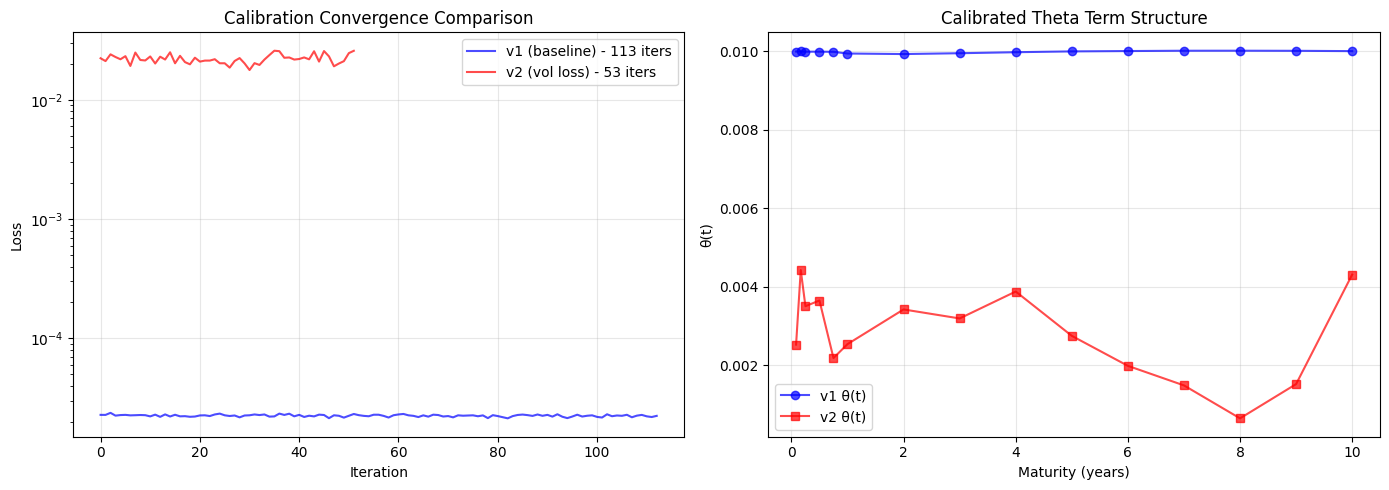


CALIBRATION COMPARISON SUMMARY
v1 - Final Loss: 2.128448e-05 | Iterations: 113
v2 - Final Loss: 1.781081e-02 | Iterations: 53


In [ ]:
# Compare convergence: v1 (baseline), v2 (vol loss)
import pickle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss convergence
ax1 = axes[0]
try:
    with open(Path('../../../../data/multi_theta_baseline.pkl'), 'rb') as f:
        v1_data = pickle.load(f)
    ax1.plot(v1_data['history'], 'b-', alpha=0.7, label=f"v1 (baseline) - {len(v1_data['history'])} iters")
except: 
    pass

try:
    with open(Path('../../../../data/multi_theta_final.pkl'), 'rb') as f:
        v2_data = pickle.load(f)
    ax1.plot(v2_data['history'], 'r-', alpha=0.7, label=f"v2 (vol loss) - {len(v2_data['history'])} iters")
except: 
    pass

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Calibration Convergence Comparison')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Theta term structure
ax2 = axes[1]
try:
    ax2.plot(v1_data['time_to_maturities'].numpy(), v1_data['theta_values'].numpy(), 
             'b-o', label='v1 θ(t)', alpha=0.7, markersize=6)
except: 
    pass

try:
    ax2.plot(v2_data['time_to_maturities'].numpy(), v2_data['theta_values'].numpy(), 
             'r-s', label='v2 θ(t)', alpha=0.7, markersize=6)
except: 
    pass

ax2.set_xlabel('Maturity (years)')
ax2.set_ylabel('θ(t)')
ax2.set_title('Calibrated Theta Term Structure')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n" + "=" * 70)
print("CALIBRATION COMPARISON SUMMARY")
print("=" * 70)
try:
    print(f"v1 - Final Loss: {v1_data['loss']:.6e} | Iterations: {len(v1_data['history'])}")
    print(f"v2 - Final Loss: {v2_data['loss']:.6e} | Iterations: {len(v2_data['history'])}")
except:
    print("(Load checkpoint files to see full comparison)")
print("=" * 70)

## v2 Results Visualization — 3D Vol Surfaces <a name="v2-visualization"></a>

Loads the saved v2 checkpoint (`multi_theta_final.pkl`) and renders market vs model implied vol surfaces alongside calibration diagnostics.


V2 VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid inversions:     201 (40.6%)
Failed inversions:    294
  - Bounds violations: 288 (price < intrinsic or invalid)
  - Convergence fails: 6 (bisection didn't converge)
Vol RMSE:             2.061%
Model vol range:      0.02% - 7.85%
Market vol range:     0.97% - 10.58%



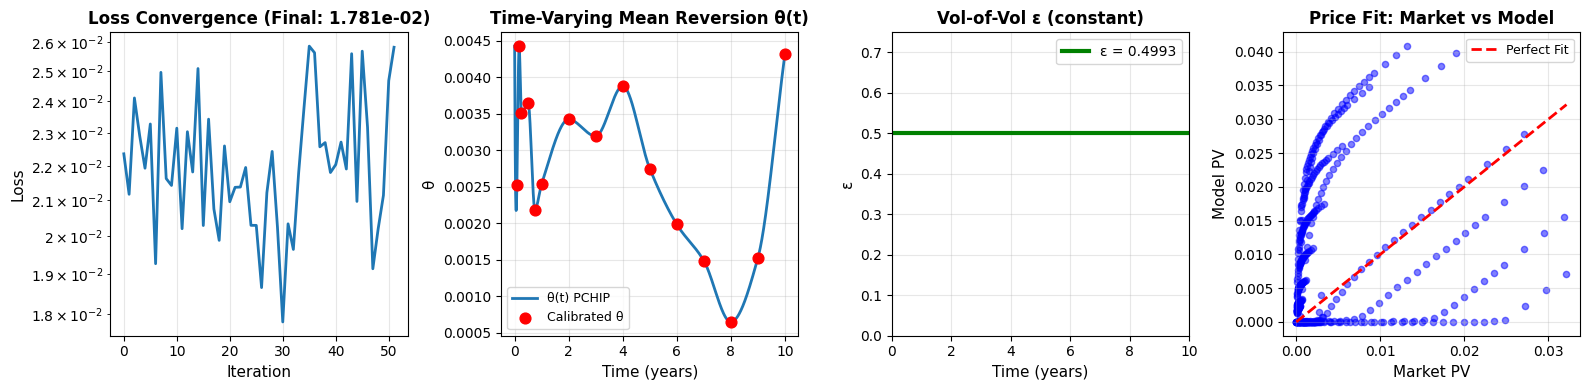


📊 Surface Coverage: 201/495 points (40.6%)
   Missing 294 points due to inversion failures



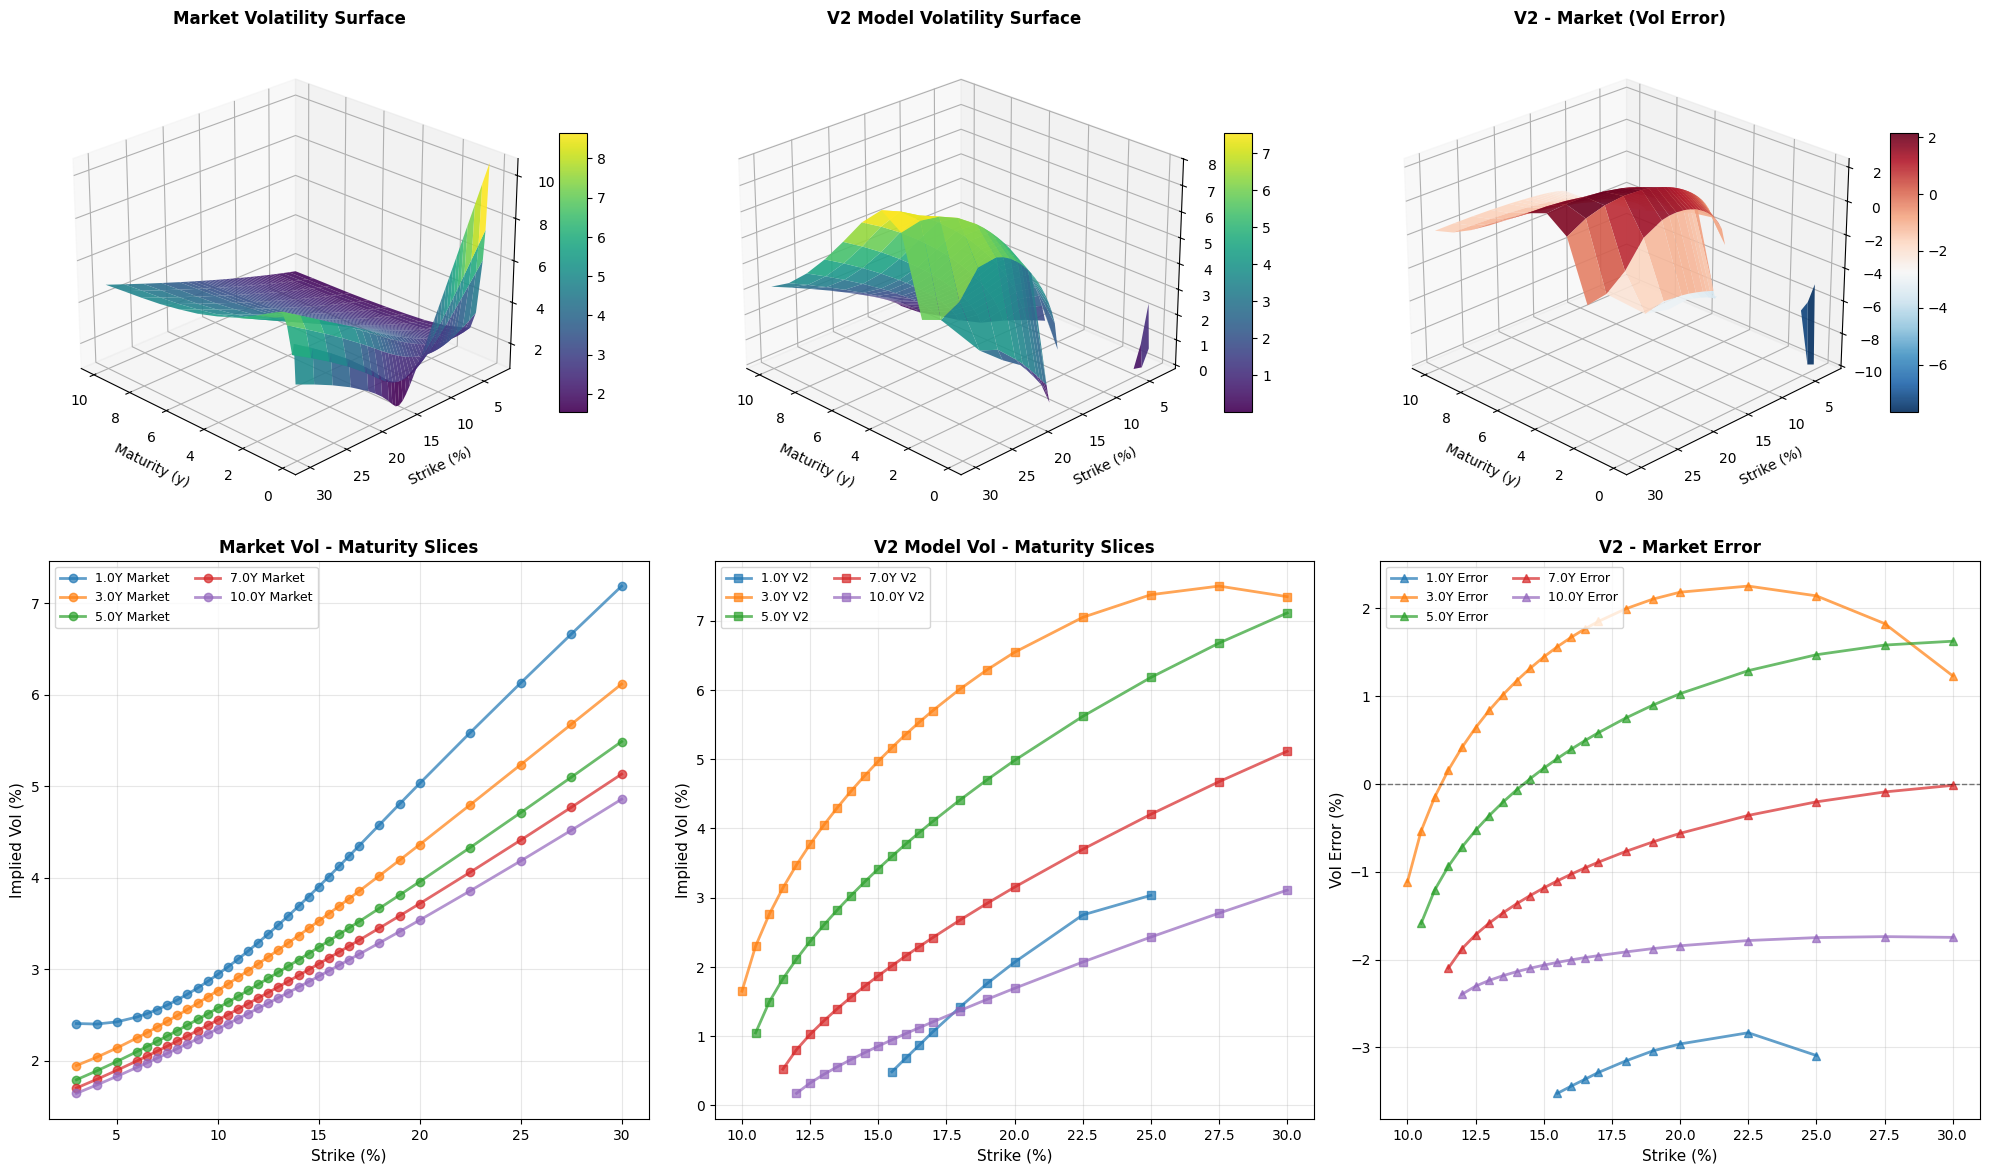

In [ ]:
# Visualization — v2 checkpoint results
import pickle
from pathlib import Path

with open(Path('../../../../data/multi_theta_final.pkl'), 'rb') as f: 
    ckpt = pickle.load(f)

# Reconstruct calibrated model
theta_t = evaluate_timeline(timeline, ckpt['time_to_maturities'], ckpt['theta_values'])
eps_t = ckpt['epsilon'] * torch.ones_like(timeline)

with torch.no_grad():
    model = create_key_rate_model(
        timeline, 500, key_ifwd_curve, ois_ifwd_curve, r0, r0,
        ckpt['v0'], ckpt['kappa'], theta_t, eps_t,
        torch.tensor(0.0), ckpt['lam'], torch.tensor(0.0), ckpt['gamma'], ckpt['xi']
    )
    price_key_caplet_surface(model, vol_key_rate, fwd_key_rate)

# Generate vol surface with diagnostics
vol_results_v2, vol_rmse_v2 = generate_vol_surface(
    model, vol_key_rate, fwd_key_rate, version_name="v2"
)

# Plot calibration diagnostics (loss history, parameters, price fit)
fig = plt.figure(figsize=(16, 4))

ax1 = fig.add_subplot(141)
ax1.plot(ckpt['history'], linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title(f"Loss Convergence (Final: {ckpt['loss']:.3e})", fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(142)
ax2.plot(timeline, theta_t, linewidth=2, label='θ(t) PCHIP')
ax2.scatter(ckpt['time_to_maturities'], ckpt['theta_values'], c='red', s=60, zorder=5, label='Calibrated θ')
ax2.set_xlabel('Time (years)', fontsize=11)
ax2.set_ylabel('θ', fontsize=11)
ax2.set_title('Time-Varying Mean Reversion θ(t)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(143)
ax3.axhline(y=ckpt['epsilon'], color='green', linewidth=3, label=f"ε = {ckpt['epsilon']:.4f}")
ax3.set_xlabel('Time (years)', fontsize=11)
ax3.set_ylabel('ε', fontsize=11)
ax3.set_title('Vol-of-Vol ε (constant)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)
ax3.set_xlim(0, 10)
ax3.set_ylim(0, ckpt['epsilon'] * 1.5)

ax4 = fig.add_subplot(144)
ax4.scatter(vol_results_v2['pv'], vol_results_v2['pv_model_key'], alpha=0.5, s=20, c='blue')
ax4.plot([0, vol_results_v2['pv'].max()], [0, vol_results_v2['pv'].max()], 'r--', lw=2, label='Perfect Fit')
ax4.set_xlabel('Market PV', fontsize=11)
ax4.set_ylabel('Model PV', fontsize=11)
ax4.set_title('Price Fit: Market vs Model', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot comprehensive vol surface comparison
plot_vol_surface_comparison(
    vol_results_v2, 
    version_name="v2", 
    plot_maturities=[1.0, 3.0, 5.0, 7.0, 10.0]
)

In [ ]:
# DIAGNOSTIC: Analyze why V2 inversions are failing
print("\n" + "="*70)
print("V2 PRICE DISTRIBUTION ANALYSIS - Understanding Inversion Failures")
print("="*70)

# Get forward rates for intrinsic value calculation
fwd_dict = {t: fwd_key_rate[fwd_key_rate['time_to_maturity']==t]['forward_rate'].values[0]
            for t in fwd_key_rate['time_to_maturity'].unique()}

# Analyze all caplets
failed_df_v2 = vol_results_v2.copy()
failed_df_v2['F'] = failed_df_v2['time_to_maturity'].map(fwd_dict)
failed_df_v2['intrinsic'] = np.maximum(failed_df_v2['F'] - failed_df_v2['strike'], 0)
failed_df_v2['price_to_intrinsic'] = failed_df_v2['pv_model_key'] / (failed_df_v2['intrinsic'] + 1e-10)

# Categorize failures  
failed_df_v2['status'] = 'Valid'
failed_df_v2.loc[failed_df_v2['pv_model_key'] <= 0, 'status'] = 'Price ≤ 0'
failed_df_v2.loc[(failed_df_v2['pv_model_key'] > 0) & (failed_df_v2['pv_model_key'] < failed_df_v2['intrinsic'] * 0.99), 'status'] = 'Price < Intrinsic'
failed_df_v2.loc[failed_df_v2['model_vol_v2'].isna() & (failed_df_v2['status'] == 'Valid'), 'status'] = 'Convergence Fail'

print(f"\nV2 Failure Breakdown:")
for status in failed_df_v2['status'].unique():
    count = (failed_df_v2['status'] == status).sum()
    pct = count / len(failed_df_v2) * 100
    print(f"  {status:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\nV2 Price Statistics:")
print(f"  Market prices:  min={failed_df_v2['pv'].min():.2e}, max={failed_df_v2['pv'].max():.2e}, mean={failed_df_v2['pv'].mean():.2e}")
print(f"  Model prices:   min={failed_df_v2['pv_model_key'].min():.2e}, max={failed_df_v2['pv_model_key'].max():.2e}, mean={failed_df_v2['pv_model_key'].mean():.2e}")
print(f"  Intrinsic vals: min={failed_df_v2['intrinsic'].min():.2e}, max={failed_df_v2['intrinsic'].max():.2e}, mean={failed_df_v2['intrinsic'].mean():.2e}")

# Compare to V1 (get counts from previous diagnostic)
print(f"\n" + "="*70)
print("V1 vs V2 COMPARISON")
print("="*70)

# Check if V1 results exist (cells 19-20 may not have been run)
if 'vol_results_v1' in dir():
    v1_valid = (~vol_results_v1['model_vol_v1'].isna()).sum()
    print(f"V1 Valid Inversions: {v1_valid}/{len(vol_results_v1)} ({v1_valid/len(vol_results_v1)*100:.1f}%)")
else:
    print("V1 Valid Inversions: Not available (run cell 19 first)")

v2_valid = (~vol_results_v2['model_vol_v2'].isna()).sum()
print(f"V2 Valid Inversions: {v2_valid}/{len(vol_results_v2)} ({v2_valid/len(vol_results_v2)*100:.1f}%)")

# Arbitrage violation counts
if 'failed_df' in dir():
    print(f"\nV1 Arbitrage Violations: {(failed_df['status'] == 'Price < Intrinsic').sum()}")
else:
    print(f"\nV1 Arbitrage Violations: Not available (run cell 20 first)")
    
print(f"V2 Arbitrage Violations: {(failed_df_v2['status'] == 'Price < Intrinsic').sum()}")
print("="*70 + "\n")


V2 PRICE DISTRIBUTION ANALYSIS - Understanding Inversion Failures

V2 Failure Breakdown:
  Valid               :  201 ( 40.6%)
  Convergence Fail    :    6 (  1.2%)
  Price ≤ 0           :   90 ( 18.2%)
  Price < Intrinsic   :  198 ( 40.0%)

V2 Price Statistics:
  Market prices:  min=3.79e-10, max=3.22e-02, mean=4.12e-03
  Model prices:   min=0.00e+00, max=4.08e-02, mean=9.64e-03
  Intrinsic vals: min=0.00e+00, max=1.33e-01, mean=2.75e-02

V1 vs V2 COMPARISON
V1 Valid Inversions: 248/495 (50.1%)
V2 Valid Inversions: 201/495 (40.6%)

V1 Arbitrage Violations: 230
V2 Arbitrage Violations: 198

